In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

from sklearn.feature_selection import VarianceThreshold
from sklearn.manifold import TSNE

import matplotlib as mpl
import locale
from matplotlib.colors import ListedColormap

In [12]:
try:
    locale.setlocale(locale.LC_ALL, 'lt_LT.UTF-8') 
except:
    locale.setlocale(locale.LC_ALL, 'lt_LT')

mpl.rcParams['axes.formatter.use_locale'] = True

ARI
TRUSTWORTHNESS CONTINOUTY
KOKIE TISKLUMO MATAI ORGINALIOJE IR MAZINTOJE 

kai statistikas skaiciuosim reikia atgal grazinti sunormuotas reimses

reikia 80 % paimti paziureti ar struktura yra stabili

In [3]:
min_max_data = pd.read_csv("full_min_max_data.csv")
tsne_results = pd.read_csv("tsne_data.csv")

In [4]:
cols_to_factor = ['credit.policy', 'not.fully.paid', 'purpose']
for col in cols_to_factor:
    min_max_data[col] = min_max_data[col].astype('category')
print(min_max_data.dtypes)

dti                   float64
fico                  float64
days.with.cr.line     float64
revol.bal             float64
revol.util            float64
inq.last.6mths        float64
delinq.2yrs           float64
pub.rec               float64
annual.inc            float64
credit.policy        category
purpose              category
not.fully.paid       category
dtype: object


# Klasterizavimas ant pilnų orginalių duomenų

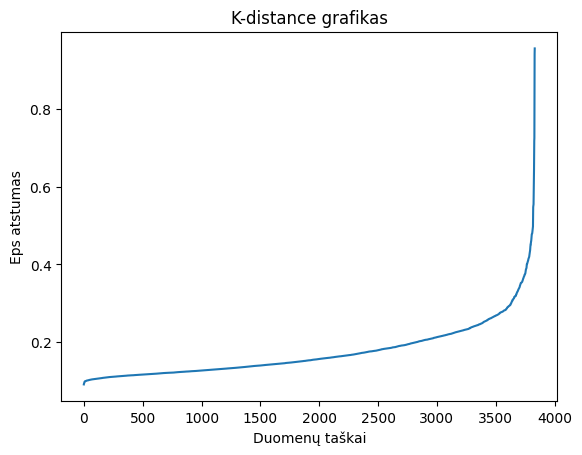

In [6]:
neighbors = NearestNeighbors(n_neighbors=18)
neighbors_fit = neighbors.fit(min_max_data.select_dtypes(include=[np.number]))
distances, indices = neighbors_fit.kneighbors(min_max_data.select_dtypes(include=[np.number]))

distances = np.sort(distances[:, 17], axis=0)
plt.plot(distances)
plt.title('K-distance grafikas')
plt.xlabel('Duomenų taškai')
plt.ylabel('Eps atstumas')
plt.show()

In [7]:
dbscan = DBSCAN(eps=0.35, min_samples=18)
clusters = dbscan.fit_predict(min_max_data.select_dtypes(include=[np.number]))

dbscan_clusters = min_max_data.copy()
dbscan_clusters['cluster'] = clusters

print(dbscan_clusters['cluster'].value_counts())

cluster
 0    3800
-1      32
Name: count, dtype: int64


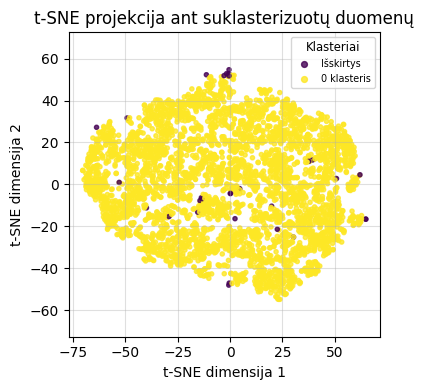

In [8]:
plt.figure(figsize=(4, 4))
scatter = plt.scatter(tsne_results.iloc[:, 0], 
                      tsne_results.iloc[:, 1], alpha=0.8, s=9, c=clusters)

plt.title("t-SNE projekcija ant suklasterizuotų duomenų")
plt.xlabel("t-SNE dimensija 1")
plt.ylabel("t-SNE dimensija 2")

handles, _ = scatter.legend_elements()
unique_labels = np.unique(clusters)
label_names = [f'{int(l)} klasteris' if l != -1 else 'Išskirtys' for l in unique_labels]
plt.legend(handles, label_names, 
           title="Klasteriai", 
           fontsize='x-small',
           title_fontsize='small',
           markerscale=0.7)
plt.grid(alpha=0.4)
plt.axis('equal')
plt.tight_layout()
plt.show()

# Klasterizavimas ant sumažintos dimensijos duomenų

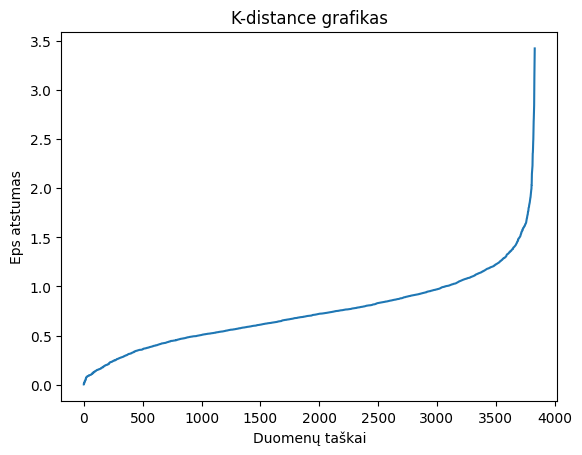

In [9]:
neighbors = NearestNeighbors(n_neighbors=8)
neighbors_fit = neighbors.fit(tsne_results)
distances, indices = neighbors_fit.kneighbors(tsne_results)

distances = np.sort(distances[:, 1], axis=0)
plt.plot(distances)
plt.title('K-distance grafikas')
plt.xlabel('Duomenų taškai')
plt.ylabel('Eps atstumas')
plt.show()

In [10]:
dbscan_tsne = DBSCAN(eps=1.25, min_samples=8)
clusters_tsne = dbscan_tsne.fit_predict(tsne_results)

dbscan_clusters_tsne = tsne_results.copy()
dbscan_clusters_tsne['cluster'] = clusters_tsne

print(dbscan_clusters_tsne['cluster'].value_counts())

cluster
-1    3770
 0      12
 1      10
 2       8
 6       8
 3       8
 5       8
 4       8
Name: count, dtype: int64


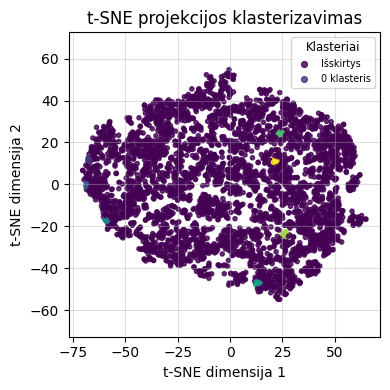

In [11]:
plt.figure(figsize=(4, 4))
scatter = plt.scatter(dbscan_clusters_tsne.iloc[:, 0], 
                      dbscan_clusters_tsne.iloc[:, 1], alpha=0.8, s=9, c=clusters_tsne)

plt.title("t-SNE projekcijos klasterizavimas")
plt.xlabel("t-SNE dimensija 1")
plt.ylabel("t-SNE dimensija 2")

handles, _ = scatter.legend_elements()
unique_labels = np.unique(clusters)
label_names = [f'{int(l)} klasteris' if l != -1 else 'Išskirtys' for l in unique_labels]
plt.legend(handles, label_names, 
           title="Klasteriai", 
           fontsize='x-small',
           title_fontsize='small',
           markerscale=0.7)
plt.grid(alpha=0.4)
plt.axis('equal')
plt.tight_layout()
plt.show()

# Paskirties grupių klasterizavimas (prieš dimensijų mažinimą)

In [8]:
filtered_data = min_max_data[min_max_data['purpose'] != 'all_other']

top_3_purposes = filtered_data['purpose'].value_counts().nlargest(3).index.tolist()

print(f"Trys dažniausios grupės: {top_3_purposes}")

debt_consolidation_data = min_max_data[min_max_data['purpose'] == top_3_purposes[0]]
credit_card_data = min_max_data[min_max_data['purpose'] == top_3_purposes[1]]
home_improvement_data = min_max_data[min_max_data['purpose'] == top_3_purposes[2]]

Trys dažniausios grupės: ['debt_consolidation', 'credit_card', 'home_improvement']


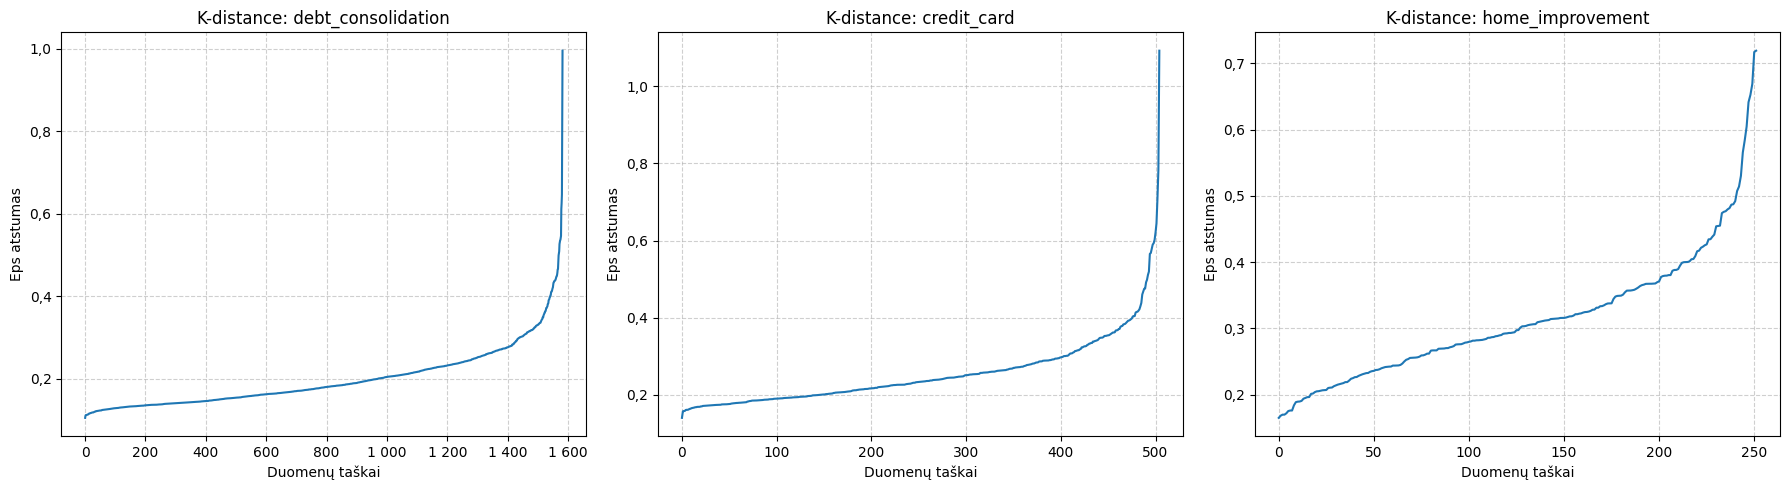

In [13]:
groups = [debt_consolidation_data, credit_card_data, home_improvement_data]
titles = top_3_purposes 

plt.figure(figsize=(18, 5))

for i, df in enumerate(groups):
    numeric_data = df.select_dtypes(include=[np.number])
    
    neighbors = NearestNeighbors(n_neighbors=18)
    neighbors_fit = neighbors.fit(numeric_data)
    distances, indices = neighbors_fit.kneighbors(numeric_data)
    
    sorted_distances = np.sort(distances[:, 17], axis=0)
    
    plt.subplot(1, 3, i + 1)
    plt.plot(sorted_distances)
    plt.title(f'K-distance: {titles[i]}')
    plt.xlabel('Duomenų taškai')
    plt.ylabel('Eps atstumas')
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [16]:
dbscan_debt_consolidation = DBSCAN(eps=0.35, min_samples=18)
clusters = dbscan_debt_consolidation.fit_predict(debt_consolidation_data.select_dtypes(include=[np.number]))

dbscan_clusters_debt_consolidation = debt_consolidation_data.copy()
dbscan_clusters_debt_consolidation['cluster'] = clusters

print(dbscan_clusters_debt_consolidation['cluster'].value_counts())

cluster
 0    1569
-1      14
Name: count, dtype: int64


In [17]:
dbscan_credit_card = DBSCAN(eps=0.4, min_samples=18)
clusters = dbscan_credit_card.fit_predict(credit_card_data.select_dtypes(include=[np.number]))

dbscan_clusters_credit_card = credit_card_data.copy()
dbscan_clusters_credit_card['cluster'] = clusters

print(dbscan_clusters_credit_card['cluster'].value_counts())

cluster
 0    496
-1      9
Name: count, dtype: int64


In [18]:
dbscan_home_improvement = DBSCAN(eps=0.45, min_samples=18)
clusters = dbscan_home_improvement.fit_predict(home_improvement_data.select_dtypes(include=[np.number]))

dbscan_clusters_home_improvement = home_improvement_data.copy()
dbscan_clusters_home_improvement['cluster'] = clusters

print(dbscan_clusters_home_improvement['cluster'].value_counts())

cluster
 0    247
-1      5
Name: count, dtype: int64


In [ ]:
tsne = TSNE(
    n_components=2, 
    random_state=42, 
    perplexity=50, 
    learning_rate=500, 
    max_iter=2000, 
    early_exaggeration=4
)

In [ ]:
datasets = [
    (dbscan_clusters_debt_consolidation, "Skolų konsolidavimas"),
    (dbscan_clusters_credit_card, "Kredito kortelė"),
    (dbscan_clusters_home_improvement, "Namų remontas")
]

custom_cmap = ListedColormap(["#1500FF", "#4FD9FC"])

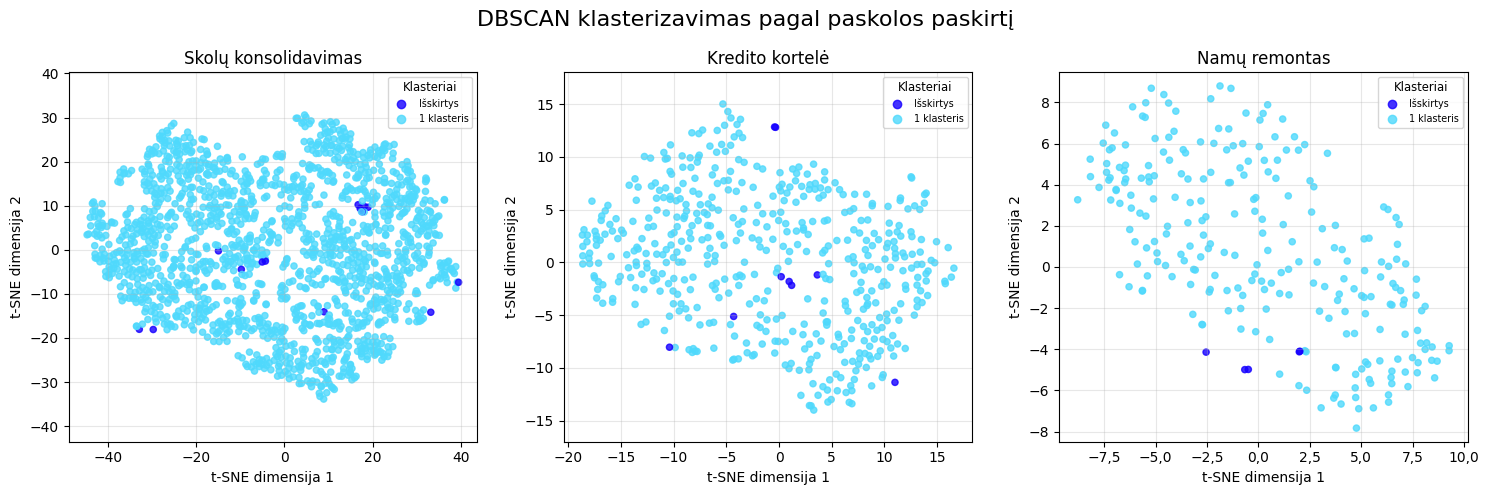

In [ ]:
plt.figure(figsize=(15, 5))

for i, (df, title) in enumerate(datasets):
    data_for_tsne = df.drop(columns=['cluster']).select_dtypes(include=[np.number])
    tsne_results = tsne.fit_transform(data_for_tsne)
    
    plt.subplot(1, 3, i + 1)
    
    clusters = df['cluster'].values
    unique_labels = np.unique(clusters)
    
    scatter = plt.scatter(
        tsne_results[:, 0], 
        tsne_results[:, 1], 
        alpha=0.8, 
        s=20, 
        c=clusters,
        cmap=custom_cmap
    )

    plt.title(f"{title}")
    plt.xlabel("t-SNE dimensija 1")
    plt.ylabel("t-SNE dimensija 2")

    handles, _ = scatter.legend_elements()
    label_names = [f'{int(l + 1)} klasteris' if l != -1 else 'Išskirtys' for l in unique_labels]
    
    plt.legend(
        handles, label_names, 
        title="Klasteriai", 
        fontsize='x-small',
        title_fontsize='small',
        markerscale=1.0
    )
    
    plt.grid(alpha=0.3)
    plt.axis('equal')

plt.suptitle("DBSCAN klasterizavimas pagal paskolos paskirtį", fontsize=16)

plt.tight_layout()
plt.show()

# Paskirties grupių klasterizavimas (po dimensijų mažinimo)

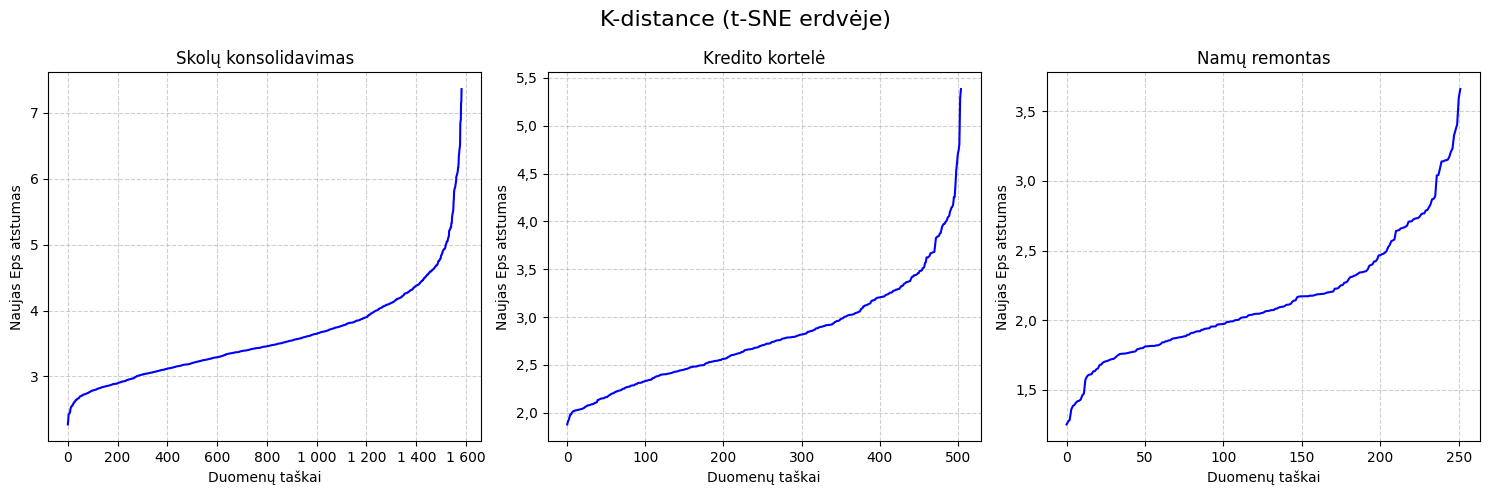

In [33]:
groups = [debt_consolidation_data, credit_card_data, home_improvement_data]
titles = ["Skolų konsolidavimas", "Kredito kortelė", "Namų remontas"]

tsne_transformed_groups = []

plt.figure(figsize=(15, 5))

for i, df in enumerate(groups):
    numeric_data = df.select_dtypes(include=[np.number])
    tsne_results = tsne.fit_transform(numeric_data)
    tsne_transformed_groups.append(tsne_results)
    
    neighbors = NearestNeighbors(n_neighbors=18)
    neighbors_fit = neighbors.fit(tsne_results)
    distances, _ = neighbors_fit.kneighbors(tsne_results)
    
    sorted_distances = np.sort(distances[:, 17], axis=0)
    
    plt.subplot(1, 3, i + 1)
    plt.plot(sorted_distances, color='blue')
    plt.title(f'{titles[i]}')
    plt.xlabel('Duomenų taškai')
    plt.ylabel('Naujas Eps atstumas')
    plt.grid(True, linestyle='--', alpha=0.6)

plt.suptitle('K-distance (t-SNE erdvėje)', fontsize=16)
plt.tight_layout()
plt.show()

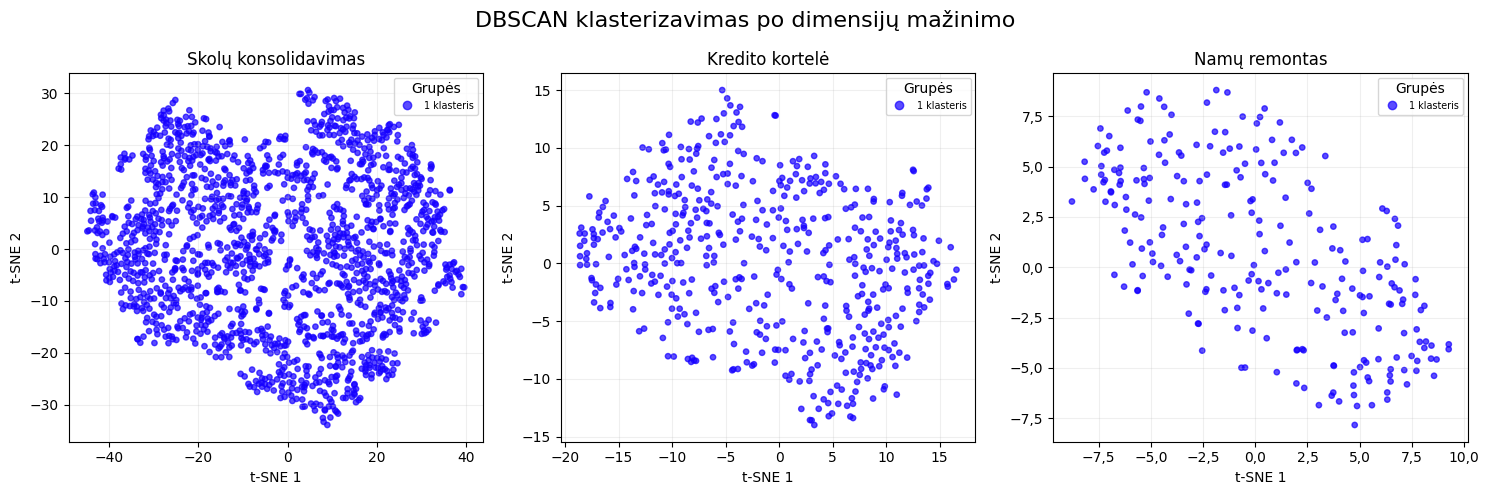

In [44]:
eps_values = [5, 4.2, 3.8]
plt.figure(figsize=(15, 5))

final_clustered_datasets = []

for i, tsne_res in enumerate(tsne_transformed_groups):
    dbscan = DBSCAN(eps=eps_values[i], min_samples=18)
    clusters = dbscan.fit_predict(tsne_res)

    df_with_clusters = groups[i].copy()
    df_with_clusters['cluster'] = clusters
    final_clustered_datasets.append(df_with_clusters)
    
    plt.subplot(1, 3, i + 1)
    
    unique_labels = np.unique(clusters)
    
    scatter = plt.scatter(
        tsne_res[:, 0], 
        tsne_res[:, 1], 
        c=clusters, 
        cmap=custom_cmap, 
        s=15, 
        alpha=0.7
    )
    
    plt.title(f"{titles[i]}", fontsize=12)
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    

    handles, _ = scatter.legend_elements()
    label_names = [f'{int(l)+1} klasteris' if l != -1 else 'Išskirtys' for l in unique_labels]
    plt.legend(handles, label_names, title="Grupės", fontsize='x-small')
    plt.grid(alpha=0.2)

plt.suptitle("DBSCAN klasterizavimas po dimensijų mažinimo", fontsize=16)
plt.tight_layout()
plt.show()

In [43]:
for i, title in enumerate(titles):
    counts = final_clustered_datasets[i]['cluster'].value_counts()
    print(f"\n{title} klasterių pasiskirstymas:\n{counts}")


Skolų konsolidavimas klasterių pasiskirstymas:
cluster
0    1583
Name: count, dtype: int64

Kredito kortelė klasterių pasiskirstymas:
cluster
0    505
Name: count, dtype: int64

Namų remontas klasterių pasiskirstymas:
cluster
0    252
Name: count, dtype: int64


# Požymių atrinkimas

## RFE

In [56]:
rfecv_debt_consolidation= pd.read_csv("rfecv_debt_consolidation.csv")
rfecv_credit_card = pd.read_csv("rfecv_credit_card.csv")
rfecv_home_improvement = pd.read_csv("rfecv_home_improvement.csv")

In [63]:
print(rfecv_debt_consolidation.shape)
print(rfecv_credit_card.shape)
print(rfecv_home_improvement.shape)

(1583, 8)
(505, 2)
(252, 5)


### Klasterizavimas prieš dimensijų mažinimą

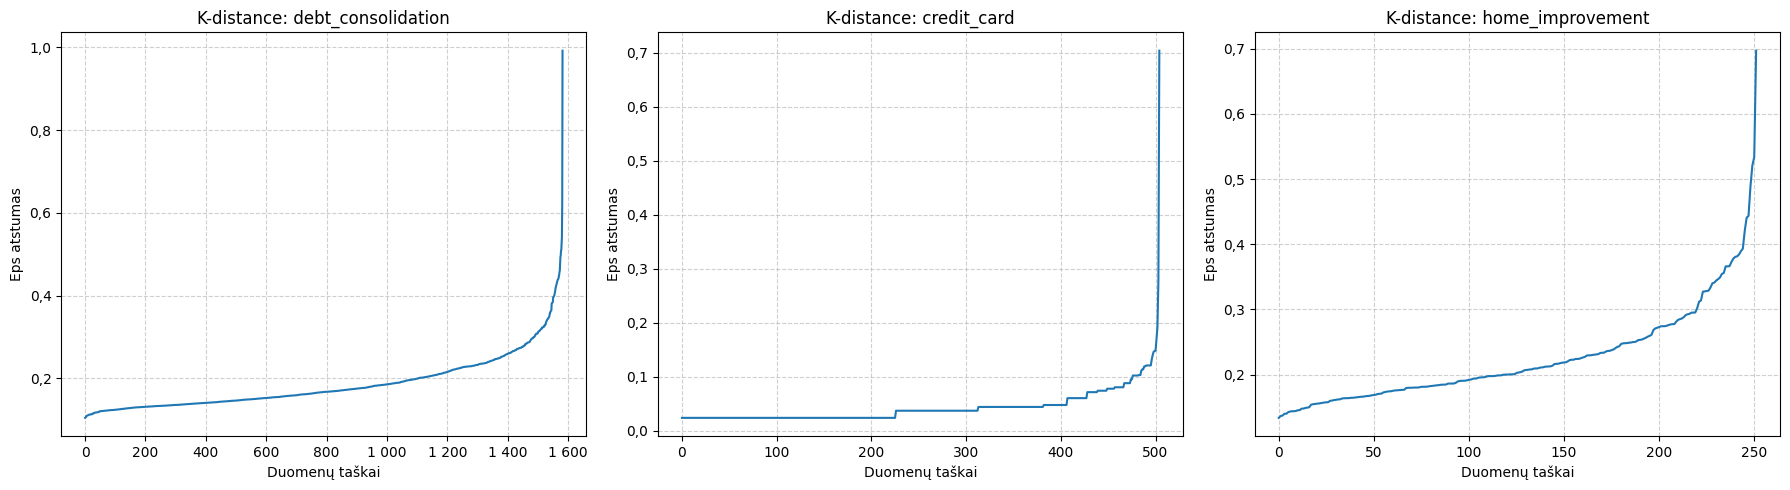

In [60]:
groups = [rfecv_debt_consolidation, rfecv_credit_card, rfecv_home_improvement]
titles = top_3_purposes 

plt.figure(figsize=(18, 5))

for i, df in enumerate(groups):
    numeric_data = df.select_dtypes(include=[np.number])
    
    neighbors = NearestNeighbors(n_neighbors=18)
    neighbors_fit = neighbors.fit(numeric_data)
    distances, indices = neighbors_fit.kneighbors(numeric_data)
    
    sorted_distances = np.sort(distances[:, 17], axis=0)
    
    plt.subplot(1, 3, i + 1)
    plt.plot(sorted_distances)
    plt.title(f'K-distance: {titles[i]}')
    plt.xlabel('Duomenų taškai')
    plt.ylabel('Eps atstumas')
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [65]:
dbscan_rfecv_debt_consolidation = DBSCAN(eps=0.4, min_samples=16)
clusters = dbscan_rfecv_debt_consolidation.fit_predict(rfecv_debt_consolidation.select_dtypes(include=[np.number]))

dbscan_clusters_rfecv_debt_consolidation = rfecv_debt_consolidation.copy()
dbscan_clusters_rfecv_debt_consolidation['cluster'] = clusters

print(dbscan_clusters_rfecv_debt_consolidation['cluster'].value_counts())

cluster
 0    1579
-1       4
Name: count, dtype: int64


In [66]:
dbscan_rfecv_credit_card = DBSCAN(eps=0.15, min_samples=4)
clusters = dbscan_rfecv_credit_card.fit_predict(rfecv_credit_card.select_dtypes(include=[np.number]))

dbscan_clusters_rfecv_credit_card = rfecv_credit_card.copy()
dbscan_clusters_rfecv_credit_card['cluster'] = clusters

print(dbscan_clusters_rfecv_credit_card['cluster'].value_counts())

cluster
 0    503
-1      2
Name: count, dtype: int64


In [69]:
dbscan_rfecv_home_improvement = DBSCAN(eps=0.4, min_samples=10)
clusters = dbscan_rfecv_home_improvement.fit_predict(rfecv_home_improvement.select_dtypes(include=[np.number]))

dbscan_clusters_rfecv_home_improvement = rfecv_home_improvement.copy()
dbscan_clusters_rfecv_home_improvement['cluster'] = clusters

print(dbscan_clusters_rfecv_home_improvement['cluster'].value_counts())

cluster
 0    251
-1      1
Name: count, dtype: int64


In [70]:
datasets = [
    (dbscan_clusters_rfecv_debt_consolidation, "Skolų konsolidavimas"),
    (dbscan_clusters_rfecv_credit_card, "Kredito kortelė"),
    (dbscan_clusters_rfecv_home_improvement, "Namų remontas")
]

custom_cmap = ListedColormap(["#1500FF", "#4FD9FC"])

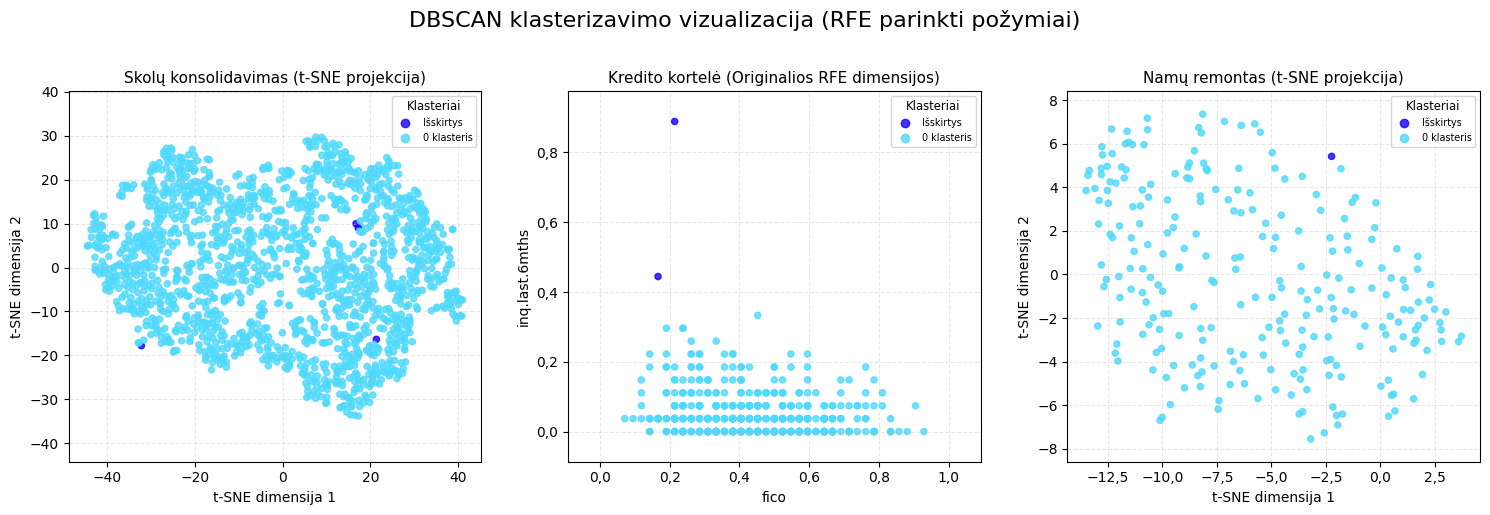

In [72]:
plt.figure(figsize=(15, 5))

for i, (df, title) in enumerate(datasets):
    plt.subplot(1, 3, i + 1)
    numeric_data = df.drop(columns=['cluster'], errors='ignore').select_dtypes(include=[np.number])
    
    if title == "Kredito kortelė":
        plot_data = numeric_data.values
        x_label, y_label = numeric_data.columns[0], numeric_data.columns[1]
        display_title = f"{title} (Originalios RFE dimensijos)"
    else:
        plot_data = tsne.fit_transform(numeric_data)
        x_label, y_label = "t-SNE dimensija 1", "t-SNE dimensija 2"
        display_title = f"{title} (t-SNE projekcija)"
    
    clusters = df['cluster'].values
    unique_labels = np.unique(clusters)
    
    scatter = plt.scatter(
        plot_data[:, 0], 
        plot_data[:, 1], 
        alpha=0.8, 
        s=20, 
        c=clusters,
        cmap=custom_cmap
    )

    plt.title(display_title, fontsize=11)
    plt.xlabel(x_label)
    plt.ylabel(y_label)

    handles, _ = scatter.legend_elements()
    label_names = [f'{int(l)} klasteris' if l != -1 else 'Išskirtys' for l in unique_labels]
    
    plt.legend(
        handles, label_names, 
        title="Klasteriai", 
        fontsize='x-small',
        title_fontsize='small',
        markerscale=1.0,
        loc='best'
    )
    
    plt.grid(alpha=0.3, linestyle='--')
    plt.axis('equal')

plt.suptitle("DBSCAN klasterizavimo vizualizacija (RFE parinkti požymiai)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### Klasterizavimas po dimensijų mažinimo

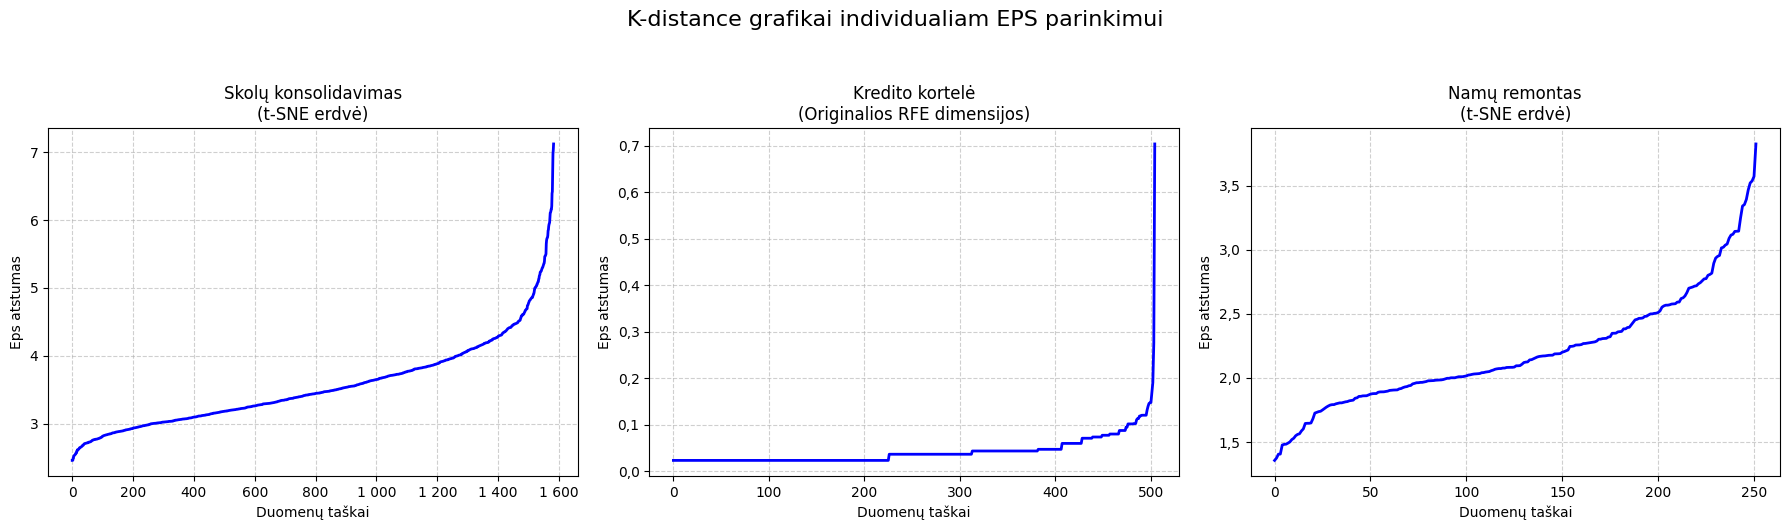

In [73]:
groups = [rfecv_debt_consolidation, rfecv_credit_card, rfecv_home_improvement]
titles = ["Skolų konsolidavimas", "Kredito kortelė", "Namų remontas"]

final_coords_for_clustering = []

plt.figure(figsize=(18, 5))

for i, df in enumerate(groups):
    numeric_data = df.select_dtypes(include=[np.number])
    
    if titles[i] == "Kredito kortelė":
        coords = numeric_data.values
        subtitle = "(Originalios RFE dimensijos)"
    else:
        coords = tsne.fit_transform(numeric_data)
        subtitle = "(t-SNE erdvė)"
    
    final_coords_for_clustering.append(coords)
    
    neighbors = NearestNeighbors(n_neighbors=18)
    neighbors_fit = neighbors.fit(coords)
    distances, _ = neighbors_fit.kneighbors(coords)
    
    sorted_distances = np.sort(distances[:, 17], axis=0)
    
    plt.subplot(1, 3, i + 1)
    plt.plot(sorted_distances, color='blue', linewidth=2)
    plt.title(f'{titles[i]}\n{subtitle}')
    plt.xlabel('Duomenų taškai')
    plt.ylabel('Eps atstumas')
    plt.grid(True, linestyle='--', alpha=0.6)

plt.suptitle('K-distance grafikai individualiam EPS parinkimui', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

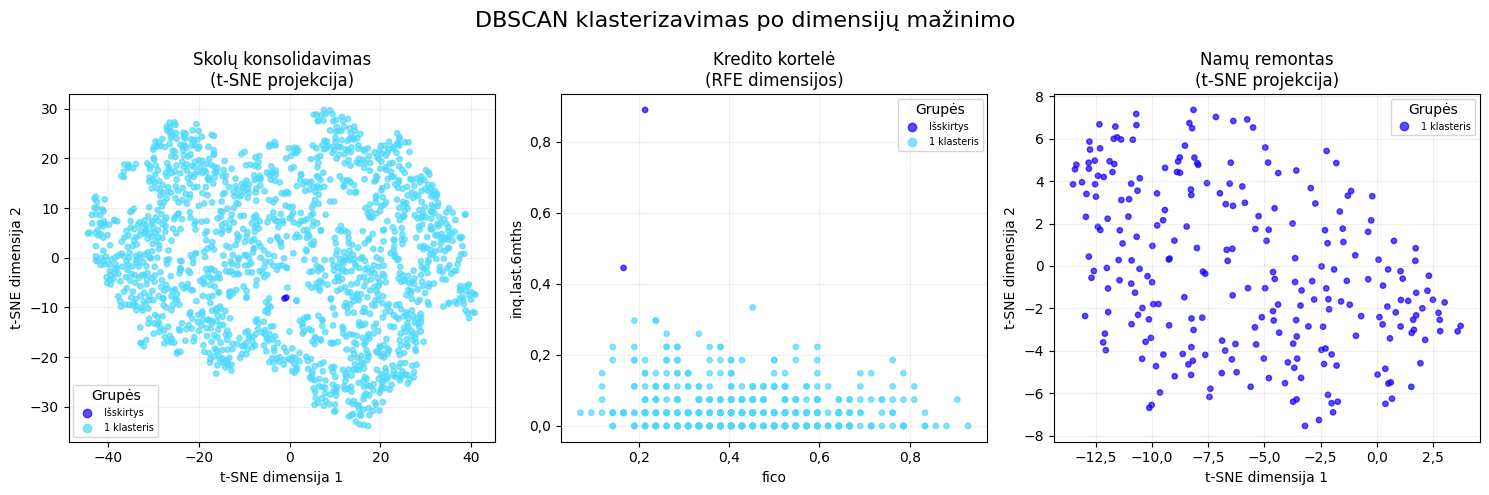

In [75]:
eps_values = [4.5, 0.15, 3.5]
min_samples_values = [16, 4, 10]
plt.figure(figsize=(15, 5))

final_clustered_datasets = []

for i, tsne_res in enumerate(final_coords_for_clustering):
    dbscan = DBSCAN(eps=eps_values[i], min_samples=min_samples_values[i])
    clusters = dbscan.fit_predict(tsne_res)

    df_with_clusters = groups[i].copy()
    df_with_clusters['cluster'] = clusters
    final_clustered_datasets.append(df_with_clusters)
    
    plt.subplot(1, 3, i + 1)
    
    unique_labels = np.unique(clusters)
    scatter = plt.scatter(
        tsne_res[:, 0], 
        tsne_res[:, 1], 
        c=clusters, 
        cmap=custom_cmap, 
        s=15, 
        alpha=0.7
    )
    
    if titles[i] == "Kredito kortelė":
        orig_cols = groups[i].select_dtypes(include=[np.number]).columns
        plt.xlabel(orig_cols[0])
        plt.ylabel(orig_cols[1])
        plt.title(f"{titles[i]}\n(RFE dimensijos)")
    else:
        plt.xlabel("t-SNE dimensija 1")
        plt.ylabel("t-SNE dimensija 2")
        plt.title(f"{titles[i]}\n(t-SNE projekcija)")

    handles, _ = scatter.legend_elements()
    label_names = [f'{int(l)+1} klasteris' if l != -1 else 'Išskirtys' for l in unique_labels]
    plt.legend(handles, label_names, title="Grupės", fontsize='x-small')
    plt.grid(alpha=0.2)

plt.suptitle("DBSCAN klasterizavimas po dimensijų mažinimo", fontsize=16)
plt.tight_layout()
plt.show()

## Pagal dispersiją

In [ ]:
selector = VarianceThreshold(threshold=0.01)
numeric_only = min_max_data.select_dtypes(include=[np.number])
variance_data = selector.fit_transform(numeric_only)

selected_cols = numeric_only.columns[selector.get_support()]
variance_subset = pd.DataFrame(variance_data, columns=selected_cols)
variance_subset.head()

,dti,fico,days.with.cr.line,revol.util
0,0.088433,0.404762,0.252568,0.901408
1,0.034633,0.285714,0.199361,0.413146
2,0.504371,0.214286,0.000000,0.448826
3,0.336247,0.333333,0.218260,0.203756
4,0.187962,0.547619,0.408971,0.646948


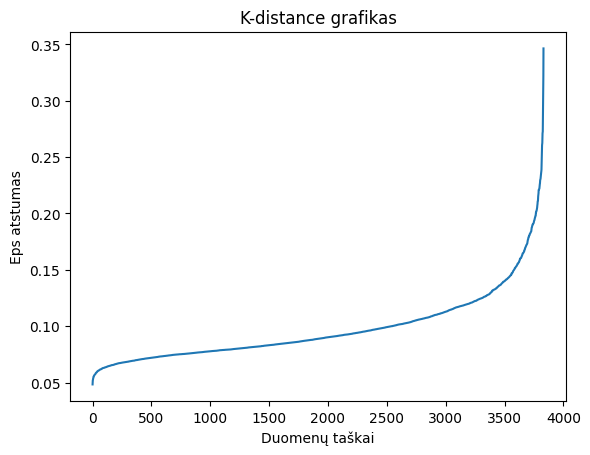

In [ ]:
neighbors = NearestNeighbors(n_neighbors=8)
neighbors_fit = neighbors.fit(variance_subset)
distances, indices = neighbors_fit.kneighbors(variance_subset)

distances = np.sort(distances[:, 7], axis=0)
plt.plot(distances)
plt.title('K-distance grafikas')
plt.xlabel('Duomenų taškai')
plt.ylabel('Eps atstumas')
plt.show()

In [ ]:
dbscan = DBSCAN(eps=0.15, min_samples=8)
clusters = dbscan.fit_predict(variance_subset)

dbscan_clusters = variance_subset.copy()
dbscan_clusters['cluster'] = clusters

print(dbscan_clusters['cluster'].value_counts())

cluster
 0    3734
-1      98
Name: count, dtype: int64


In [ ]:
tsne = TSNE(n_components=2, random_state=42, perplexity=50, learning_rate=500, max_iter=2000, early_exaggeration=4)
tsne_results = tsne.fit_transform(dbscan_clusters.drop(columns=['cluster']))

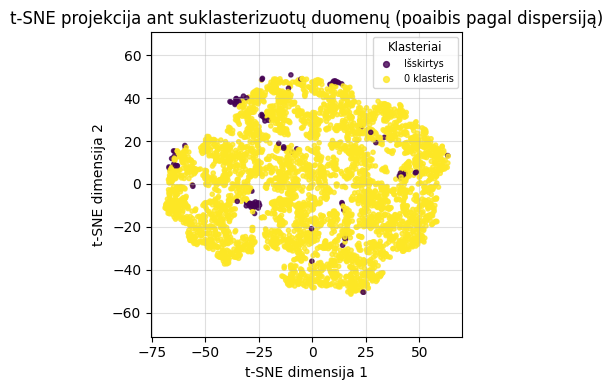

In [ ]:
tsne_df = pd.DataFrame(tsne_results, columns=['tsne_1', 'tsne_2'])
plt.figure(figsize=(4, 4))
scatter = plt.scatter(tsne_df['tsne_1'], 
                      tsne_df['tsne_2'], alpha=0.8, s=9, c=dbscan_clusters['cluster'],)

plt.title("t-SNE projekcija ant suklasterizuotų duomenų (poaibis pagal dispersiją)")
plt.xlabel("t-SNE dimensija 1")
plt.ylabel("t-SNE dimensija 2")

handles, _ = scatter.legend_elements()
unique_labels = np.unique(clusters)
label_names = [f'{int(l)} klasteris' if l != -1 else 'Išskirtys' for l in unique_labels]
plt.legend(handles, label_names, 
           title="Klasteriai", 
           fontsize='x-small',
           title_fontsize='small',
           markerscale=0.7)
plt.grid(alpha=0.4)
plt.axis('equal')
plt.tight_layout()
plt.show()

In [30]:
tsne = TSNE(n_components=2, random_state=42, perplexity=50, learning_rate=500, max_iter=2000, early_exaggeration=4)
tsne_results = tsne.fit_transform(variance_subset)

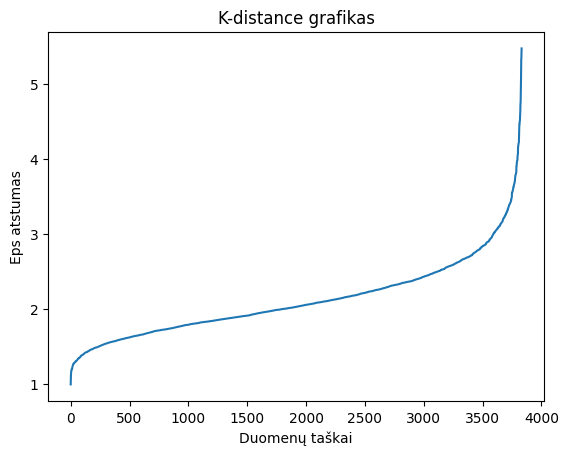

In [31]:
neighbors = NearestNeighbors(n_neighbors=8)
neighbors_fit = neighbors.fit(tsne_results)
distances, indices = neighbors_fit.kneighbors(tsne_results)

distances = np.sort(distances[:, 7], axis=0)
plt.plot(distances)
plt.title('K-distance grafikas')
plt.xlabel('Duomenų taškai')
plt.ylabel('Eps atstumas')
plt.show()

In [33]:
dbscan_tsne = DBSCAN(eps=3, min_samples=8)
clusters_tsne = dbscan_tsne.fit_predict(tsne_results)

dbscan_clusters_tsne = pd.DataFrame(tsne_results, columns=['tsne_1', 'tsne_2'])
dbscan_clusters_tsne['cluster'] = clusters_tsne
print(dbscan_clusters_tsne['cluster'].value_counts())

cluster
 0    3768
-1      47
 1       9
 2       8
Name: count, dtype: int64


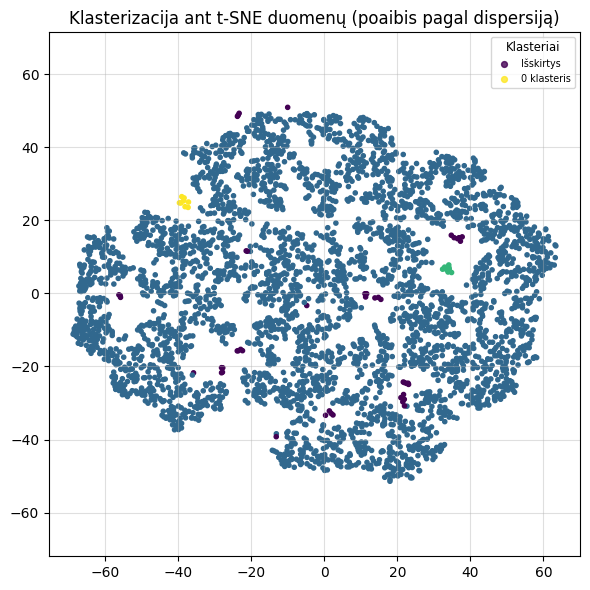

In [41]:
plt.figure(figsize=(6, 6))
plt.scatter(dbscan_clusters_tsne['tsne_1'], 
            dbscan_clusters_tsne['tsne_2'], 
            c=dbscan_clusters_tsne['cluster'], 
            cmap='viridis', s=9)
plt.title("Klasterizacija ant t-SNE duomenų (poaibis pagal dispersiją)")

handles, _ = scatter.legend_elements()
unique_labels = np.unique(dbscan_clusters_tsne['cluster'])
label_names = [f'{int(l)} klasteris' if l != -1 else 'Išskirtys' for l in unique_labels]
plt.legend(handles, label_names, 
           title="Klasteriai", 
           fontsize='x-small',
           title_fontsize='small',
           markerscale=0.7)
plt.grid(alpha=0.4)
plt.axis('equal')
plt.tight_layout()
plt.show()